# Palm Fruit Ripeness Classification — ShuffleNetV2

This notebook trains and evaluates a palm fruit ripeness classifier with a **custom ShuffleNetV2** backbone built in TensorFlow/Keras (no PyTorch dependency). It follows the same workflow, directory layout, artifact naming, and evaluation protocol as the MobileNetV2 baseline so results can be compared directly in `reports/experiment_log.csv`.

### Key design decisions vs MobileNetV2 baseline
1. **ShuffleNetV2 backbone**: implemented from scratch in TF/Keras using channel split + shuffle operations. Width multiplier `1.0` targets a similar parameter budget to MobileNetV2.
2. **Preprocessing**: simple `x / 127.5 - 1.0` (scale to [-1, 1]) — no Keras application `preprocess_input` needed because the backbone is custom.  A single `preprocess_fn` is applied consistently in training, representative-dataset generation, and runtime inference.
3. **Same output contracts**: produces `palm_ripeness_best_<timestamp>.h5`, `experiment_log.csv`, confusion matrix PNG, metrics bar-chart PNG, Excel report, and all three TFLite variants via `scripts/convert_tflite.py`.
4. **Run modes**: `DO_SMOKE`, `DO_TRAIN`, `DO_FINE_TUNE` flags mirror the MobileNetV2 notebook for easy side-by-side comparison.


In [32]:
import os
import datetime
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras import utils
from sklearn.metrics import classification_report, confusion_matrix

# ─── User config (edit as needed) ───────────────────────────────────────────
DATASET_ROOT = os.getenv("DATASET_ROOT", r"C:\\Users\\jeffy\\Documents\\PSM\\Dataset1")
TRAIN_ROOT   = os.getenv("TRAIN_ROOT", os.path.join(DATASET_ROOT, "Train"))
TEST_ROOT    = os.getenv("TEST_ROOT",  os.path.join(DATASET_ROOT, "Test"))

IMG_SIZE    = (224, 224)   # Must match MobileNetV2 baseline for fair comparison
BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE
SEED        = 42
VAL_SPLIT   = 0.2          # 20% of training data reserved for validation

# ShuffleNetV2 width multiplier: 1.0 → output channels [116, 232, 464, 1024]
WIDTH_MULT  = 1.0          # Options: 0.5 | 1.0 | 1.5 | 2.0

# Run modes — match MobileNetV2 notebook flags exactly
DO_TRAIN          = True   # Full training with frozen head stage
DO_SMOKE          = False  # 1-epoch sanity check (fast pipeline validation)
DO_FINE_TUNE      = True   # Unfreeze top layers and continue at lower LR
SMOKE_TRAIN_STEPS = 100
SMOKE_VAL_STEPS   = 20
EPOCHS            = 30     # Frozen-head training epochs
FINE_TUNE_EPOCHS  = 15     # Extra epochs for fine-tune phase

# Output directory — same as all other model notebooks
MODEL_DIR = "saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)
TIMESTAMP = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"Timestamp: {TIMESTAMP}")
print(f"ShuffleNetV2 width multiplier: {WIDTH_MULT}")


TensorFlow version: 2.20.0
GPU available: []
Timestamp: 20260423_224710
ShuffleNetV2 width multiplier: 1.0


## 2. Load & Split Datasets

The training directory is split into **80 % train / 20 % validation** via `validation_split`.  
The test directory is loaded only for final evaluation so callbacks never see test data.

Included safeguards:
- Filesystem counts per class are printed to catch empty folders early.
- A missing or empty training set raises a clear error.
- Detected class names are stored for later evaluation and plotting.


In [33]:
# ─── Helper: count image files per class ────────────────────────────────────
def count_images(root):
    """Count image files per class folder. Returns (dict of counts, total)."""
    counts = {}
    total  = 0
    if not os.path.exists(root):
        return counts, total
    for cls in sorted(os.listdir(root)):
        p = os.path.join(root, cls)
        if os.path.isdir(p):
            files = [f for f in os.listdir(p)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            counts[cls] = len(files)
            total += len(files)
    return counts, total

train_counts, train_total = count_images(TRAIN_ROOT)
test_counts,  test_total  = count_images(TEST_ROOT)
print("Filesystem counts:")
print("  Train:", train_counts, "=>", train_total)
print("  Test :", test_counts,  "=>", test_total)

if train_total == 0:
    raise FileNotFoundError(f"No training images found under {TRAIN_ROOT}")

# ─── Create tf.data datasets with proper train/val split ────────────────────
train_ds = utils.image_dataset_from_directory(
    TRAIN_ROOT,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="training",
)

val_ds = utils.image_dataset_from_directory(
    TRAIN_ROOT,
    labels="inferred",
    label_mode="categorical",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=VAL_SPLIT,
    subset="validation",
)

# Test set — loaded only for final evaluation (never seen during training)
test_ds = None
if test_total > 0:
    test_ds = utils.image_dataset_from_directory(
        TEST_ROOT,
        labels="inferred",
        label_mode="categorical",
        batch_size=BATCH_SIZE,
        image_size=IMG_SIZE,
        shuffle=False,
    )

class_names = train_ds.class_names
num_classes  = len(class_names)
print("Detected classes:", class_names)
print(f"Num classes: {num_classes}")


Filesystem counts:
  Train: {'Overripe': 400, 'Ripe': 400, 'Underripe': 400} => 1200
  Test : {'Overripe': 60, 'Ripe': 60, 'Underripe': 60} => 180
Found 1200 files belonging to 3 classes.
Using 960 files for training.
Found 1200 files belonging to 3 classes.
Using 240 files for validation.
Found 180 files belonging to 3 classes.
Detected classes: ['Overripe', 'Ripe', 'Underripe']
Num classes: 3


## 3. Preprocessing

ShuffleNetV2 has **no Keras application `preprocess_input`** because the backbone is custom-built.  
We use the same [-1, 1] scale as MobileNetV2 (`x / 127.5 - 1.0`) so the two models see identical input ranges and the comparison is fair.

**Single preprocessing source rule**: `preprocess_fn` is defined once here and reused in:
- `train_ds_pp` / `val_ds_pp` / `test_ds_pp` (training pipeline)
- The TFLite representative-dataset generator inside `scripts/convert_tflite.py` (pass `--preprocess-family shufflenet`)
- `scripts/pi_inference.py` runtime path (pass `--preprocess-family shufflenet`)


In [34]:
# ─── Preprocessing ──────────────────────────────────────────────────────────
# ShuffleNetV2 expects inputs in [-1, 1] — same range as MobileNetV2.
# Cast to float32 first; raw image_dataset_from_directory yields uint8 tensors.
def preprocess_fn(x, y):
    x = tf.cast(x, tf.float32)
    x = x / 127.5 - 1.0          # scale uint8 [0, 255] → float32 [-1, 1]
    return x, y

train_ds_pp = train_ds.map(preprocess_fn, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds_pp   = val_ds.map(preprocess_fn,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

test_ds_pp = None
if test_ds is not None:
    test_ds_pp = test_ds.map(preprocess_fn, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Preprocessing applied: float32 [-1, 1] (x / 127.5 - 1.0)")
print("IMPORTANT — runtime inference MUST apply the same scaling before passing")
print("images to the TFLite interpreter (--preprocess-family shufflenet).")


Preprocessing applied: float32 [-1, 1] (x / 127.5 - 1.0)
IMPORTANT — runtime inference MUST apply the same scaling before passing
images to the TFLite interpreter (--preprocess-family shufflenet).


## 4. Build Model — ShuffleNetV2 Backbone

ShuffleNetV2 (Ma et al., 2018) replaces group convolutions with **channel split + shuffle** operations that are both fast and hardware-friendly.

### Architecture overview
```
Input (224×224×3)
  └─ Stem conv 3×3 stride-2 → 24 channels
  └─ MaxPool 3×3 stride-2
  └─ Stage 2 (4 blocks)  → 116 channels  (width_mult=1.0)
  └─ Stage 3 (8 blocks)  → 232 channels
  └─ Stage 4 (4 blocks)  → 464 channels
  └─ Conv 1×1 → 1024 channels
  └─ GlobalAveragePooling2D
  └─ Dropout → Dense(128, relu) → BatchNorm → Dropout → Dense(num_classes, softmax)
```

The **ShuffleNetV2 block** splits input channels into two branches:
- **Branch 1**: identity (left half) — no computation.
- **Branch 2**: DW-Conv → BN → Conv1×1 → BN → ReLU → DW-Conv → BN → Conv1×1 → BN → ReLU (right half).
- Outputs are concatenated, then channel-shuffled to mix information.

The **stride-2 downsampling block** applies both branches with a DW-Conv stride-2 on the left and the full sequence on the right.


In [35]:
# ─── ShuffleNetV2 channel-output table ──────────────────────────────────────
# Indexed by width multiplier: 0.5 | 1.0 | 1.5 | 2.0
_CHANNELS = {
    0.5: [48, 96, 192, 1024],
    1.0: [116, 232, 464, 1024],
    1.5: [176, 352, 704, 1024],
    2.0: [244, 488, 976, 2048],
}


def _channel_shuffle(x, groups=2):
    """Channel shuffle implemented with serializable Keras layers."""
    height = x.shape[1]
    width = x.shape[2]
    channels = x.shape[-1]
    if height is None or width is None or channels is None:
        raise ValueError("ShuffleNetV2 requires static spatial and channel dimensions.")
    if channels % groups != 0:
        raise ValueError(f"channels={channels} must be divisible by groups={groups}")

    x = layers.Reshape((int(height), int(width), groups, channels // groups))(x)
    x = layers.Permute((1, 2, 4, 3))(x)
    x = layers.Reshape((int(height), int(width), channels))(x)
    return x


def _dw_conv_bn(x, stride=1):
    """Depthwise Conv2D + BatchNorm."""
    x = layers.DepthwiseConv2D(3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return x


def _pw_conv_bn_relu(x, filters):
    """Pointwise Conv1x1 + BatchNorm + ReLU."""
    x = layers.Conv2D(filters, 1, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def shufflenet_v2_basic_block(x, out_channels):
    """
    ShuffleNetV2 basic block (stride=1).
    Canonical ordering: split -> pointwise -> depthwise -> pointwise -> shuffle.
    """
    channels = x.shape[-1]
    if channels != out_channels:
        raise ValueError(f"Expected {out_channels} channels, got {channels}")
    half = out_channels // 2

    x_left = x[:, :, :, :half]
    x_right = x[:, :, :, half:]

    x_right = _pw_conv_bn_relu(x_right, half)
    x_right = _dw_conv_bn(x_right, stride=1)
    x_right = _pw_conv_bn_relu(x_right, half)

    out = layers.Concatenate()([x_left, x_right])
    out = _channel_shuffle(out, groups=2)
    return out


def shufflenet_v2_stride2_block(x, out_channels):
    """
    ShuffleNetV2 stride-2 downsampling block.
    Both branches process the full input and then concatenate.
    """
    half = out_channels // 2

    x_left = _dw_conv_bn(x, stride=2)
    x_left = _pw_conv_bn_relu(x_left, half)

    x_right = _pw_conv_bn_relu(x, half)
    x_right = _dw_conv_bn(x_right, stride=2)
    x_right = _pw_conv_bn_relu(x_right, half)

    out = layers.Concatenate()([x_left, x_right])
    out = _channel_shuffle(out, groups=2)
    return out


def build_shufflenet_v2(input_shape, num_classes, width_mult=1.0, dropout_rate=0.3):
    """
    Build a canonical ShuffleNetV2 model for comparison against MobileNetV2.

    The stage repeat values below are the number of basic blocks *after* the
    initial stride-2 block in each stage. That gives total stage depths of
    4, 8, and 4 blocks respectively, matching the usual ShuffleNetV2-1.0 layout.
    """
    assert width_mult in _CHANNELS, f"width_mult must be one of {list(_CHANNELS)}"
    stage_channels = _CHANNELS[width_mult]
    stage_basic_blocks = [3, 7, 3]

    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.1),
    ], name="data_augmentation")

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)

    x = layers.Conv2D(24, 3, strides=2, padding="same", use_bias=False, name="stem_conv")(x)
    x = layers.BatchNormalization(name="stem_bn")(x)
    x = layers.ReLU(name="stem_relu")(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same", name="stem_pool")(x)

    for out_channels, num_basic_blocks in zip(stage_channels[:3], stage_basic_blocks):
        x = shufflenet_v2_stride2_block(x, out_channels)
        for _ in range(num_basic_blocks):
            x = shufflenet_v2_basic_block(x, out_channels)

    x = _pw_conv_bn_relu(x, stage_channels[3])
    x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(128, activation="relu", name="head_dense1")(x)
    x = layers.BatchNormalization(name="head_bn")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = Model(inputs, outputs, name=f"ShuffleNetV2_x{width_mult}")
    return model


# ── Instantiate & compile ────────────────────────────────────────────────────
model = build_shufflenet_v2(
    input_shape=IMG_SIZE + (3,),
    num_classes=num_classes,
    width_mult=WIDTH_MULT,
    dropout_rate=0.3,
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()
print(f"\nTotal params: {model.count_params():,}")

Model: "ShuffleNetV2_x1.0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_8[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        648 │ data_augmentatio… │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │         96 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│                     │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 56, 56,    │          0 │ stem_relu[0][0]   │
│ (MaxPooling2D)      │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_151 (Conv2D) │ (None, 56, 56,    │      1,392 │ stem_pool[0][0]   │
│                     │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        232 │ conv2d_151[0][0]  │
│ (BatchNormalizatio… │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_151 (ReLU)    │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_95 │ (None, 28, 28,    │        216 │ stem_pool[0][0]   │
│ (DepthwiseConv2D)   │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_96 │ (None, 28, 28,    │        522 │ re_lu_151[0][0]   │
│ (DepthwiseConv2D)   │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │         96 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 24)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        232 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_150 (Conv2D) │ (None, 28, 28,    │      1,392 │ batch_normalizat… │
│                     │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_152 (Conv2D) │ (None, 28, 28,    │      3,364 │ batch_normalizat… │
│                     │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        232 │ conv2d_150[0][0]  │
│ (BatchNormalizatio… │ 58)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        232 │ conv2d_152[0][0]

 Total params: 1,401,883 (5.35 MB)

 Trainable params: 1,385,447 (5.29 MB)

 Non-trainable params: 16,436 (64.20 KB)


Total params: 1,401,883


## 5. Callbacks & Training

Training uses **EarlyStopping** and **ReduceLROnPlateau** keyed to `val_loss`.  
Checkpoints are timestamped to avoid overwriting past runs.

**Fine-tuning strategy for ShuffleNetV2**: because all weights are randomly initialised (no ImageNet pretrained backbone), fine-tuning in this context means re-compiling at a lower learning rate and running extra epochs with all layers trainable — equivalent to the head-only warm-up completed, then a full-network low-LR continuation.  
`DO_FINE_TUNE=True` is therefore still useful to squeeze out a few extra accuracy points after the plateau.


In [36]:
# ─── Callbacks ──────────────────────────────────────────────────────────────
monitor_metric  = "val_loss" if val_ds_pp is not None else "loss"
best_model_path = os.path.join(MODEL_DIR, f"palm_ripeness_best_{TIMESTAMP}.h5")
final_model_path = os.path.join(MODEL_DIR, f"palm_ripeness_final_{TIMESTAMP}.h5")

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor=monitor_metric, patience=7, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor=monitor_metric, factor=0.5, patience=4, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        best_model_path, monitor=monitor_metric, save_best_only=True
    ),
]

# ─── Smoke Test ──────────────────────────────────────────────────────────────
if DO_SMOKE:
    print("\n--- Smoke test (1 epoch) to validate the pipeline ---")
    smoke_train = train_ds_pp.take(SMOKE_TRAIN_STEPS)
    smoke_val   = val_ds_pp.take(SMOKE_VAL_STEPS) if val_ds_pp is not None else None
    history = model.fit(
        smoke_train, epochs=1, validation_data=smoke_val,
        callbacks=callbacks, verbose=1
    )
    print("Smoke test done. Metrics:", {k: round(v[-1], 4) for k, v in history.history.items()})

# ─── Full Training (all layers from scratch) ─────────────────────────────────
if DO_TRAIN:
    print("\n--- Full training (ShuffleNetV2 — all weights random init) ---")
    history = model.fit(
        train_ds_pp,
        epochs=EPOCHS,
        validation_data=val_ds_pp,
        callbacks=callbacks,
        verbose=1,
    )
    model.save(final_model_path)
    print(f"Saved initial model to {final_model_path}")

# ─── Fine-Tuning Phase ────────────────────────────────────────────────────────
# For ShuffleNetV2 (no pretrained backbone), fine-tuning = lower LR continuation
# with all layers trainable. Equivalent role to MobileNetV2 backbone unfreezing.
if DO_FINE_TUNE and DO_TRAIN:
    print("\n--- Fine-tuning: recompile at lower LR, all layers trainable ---")
    for layer in model.layers:
        layer.trainable = True

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    ft_model_path = os.path.join(MODEL_DIR, f"palm_ripeness_finetuned_{TIMESTAMP}.h5")
    ft_callbacks = [
        keras.callbacks.EarlyStopping(
            monitor=monitor_metric, patience=5, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor=monitor_metric, factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            ft_model_path, monitor=monitor_metric, save_best_only=True
        ),
    ]

    model.fit(
        train_ds_pp,
        epochs=FINE_TUNE_EPOCHS,
        validation_data=val_ds_pp,
        callbacks=ft_callbacks,
        verbose=1,
    )
    model.save(ft_model_path)
    print(f"Saved fine-tuned model to {ft_model_path}")

elif DO_FINE_TUNE and not DO_TRAIN:
    print("Skipping fine-tuning: DO_TRAIN must be True first.")



--- Full training (ShuffleNetV2 — all weights random init) ---
Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.3230 - loss: 1.6220

30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 442ms/step - accuracy: 0.3302 - loss: 1.6589 - val_accuracy: 0.3417 - val_loss: 1.0983 - learning_rate: 1.0000e-04
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 369ms/step - accuracy: 0.3854 - loss: 1.4926 - val_accuracy: 0.3417 - val_loss: 1.1100 - learning_rate: 1.0000e-04
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 392ms/step - accuracy: 0.4042 - loss: 1.3742 - val_accuracy: 0.3417 - val_loss: 1.1364 - learning_rate: 1.0000e-04
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 376ms/step - accuracy: 0.4021 - loss: 1.4031 - val_accuracy: 0.3417 - val_loss: 1.1694 - learning_rate: 1.0000e-04
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.4226 - loss: 1.3506
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 361ms/step - accuracy: 0.4115 - loss: 1.3421 - val_accuracy: 0.3417 - val_loss: 1.2208 - learning_rate: 1.0000e-04
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 350ms/step - accuracy: 0.4052 - l

Saved initial model to saved_models\palm_ripeness_final_20260423_224710.h5

--- Fine-tuning: recompile at lower LR, all layers trainable ---
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.3882 - loss: 1.5335

30/30 ━━━━━━━━━━━━━━━━━━━━ 34s 407ms/step - accuracy: 0.3750 - loss: 1.5463 - val_accuracy: 0.3417 - val_loss: 1.1108 - learning_rate: 1.0000e-05
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 347ms/step - accuracy: 0.3865 - loss: 1.5132 - val_accuracy: 0.3417 - val_loss: 1.1377 - learning_rate: 1.0000e-05
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step - accuracy: 0.3812 - loss: 1.5078 - val_accuracy: 0.3417 - val_loss: 1.1770 - learning_rate: 1.0000e-05
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.3723 - loss: 1.5223
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 355ms/step - accuracy: 0.3833 - loss: 1.4748 - val_accuracy: 0.3417 - val_loss: 1.2359 - learning_rate: 1.0000e-05
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 364ms/step - accuracy: 0.3823 - loss: 1.5215 - val_accuracy: 0.3417 - val_loss: 1.3081 - learning_rate: 5.0000e-06
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 358ms/step - accuracy: 0.3760 - l

Saved fine-tuned model to saved_models\palm_ripeness_finetuned_20260423_224710.h5


## 6. Evaluation on Test Set

The held-out test set is used **exactly once** after training.  
Both labels and predictions are derived from the same preprocessed pipeline to keep arrays aligned before computing classification metrics and the confusion matrix.


In [37]:
# ─── Evaluation ─────────────────────────────────────────────────────────────
report_dict = {}
cm   = None
y_true = np.array([])
y_pred = np.array([])

if test_ds_pp is not None:
    print("\n--- Evaluating on held-out test set ---")
    y_true_list = []
    y_pred_list = []

    for x_batch, y_batch in test_ds_pp:
        preds = model.predict(x_batch, verbose=0)
        y_pred_list.append(np.argmax(preds, axis=1))
        y_true_list.append(np.argmax(y_batch.numpy(), axis=1))

    y_true = np.concatenate(y_true_list)
    y_pred = np.concatenate(y_pred_list)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    report_dict = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True
    )

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)
else:
    print("No test set found — skipping evaluation.")



--- Evaluating on held-out test set ---



Classification Report:
              precision    recall  f1-score   support

    Overripe       0.00      0.00      0.00        60
        Ripe       0.33      1.00      0.50        60
   Underripe       0.00      0.00      0.00        60

    accuracy                           0.33       180
   macro avg       0.11      0.33      0.17       180
weighted avg       0.11      0.33      0.17       180

Confusion Matrix:
[[ 0 60  0]
 [ 0 60  0]
 [ 0 60  0]]


C:\Users\jeffy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jeffy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jeffy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

## 6a. Visualise Results & Export to Excel

Generates a confusion matrix heatmap and a grouped precision/recall/F1 bar chart, saves both as `.png`, and exports the full classification report plus confusion matrix to a multi-sheet Excel workbook for reporting.

Output files (written to `saved_models/`):
- `confusion_matrix_<timestamp>.png`
- `classification_metrics_<timestamp>.png`
- `classification_report_<timestamp>.xlsx`


Confusion matrix saved to saved_models\confusion_matrix_20260423_224710.png


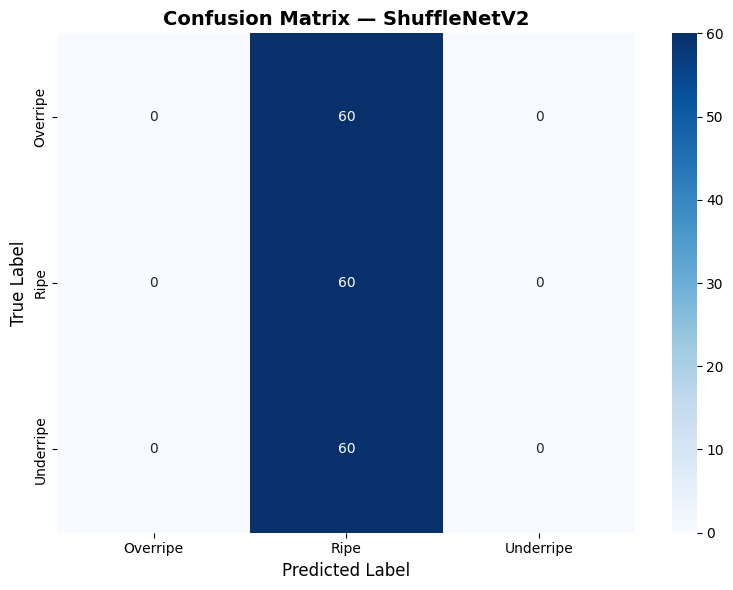

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

if cm is None:
    print("Skipping confusion matrix plot: run evaluation first.")
else:
    fig_cm, ax_cm = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax_cm,
    )
    ax_cm.set_xlabel("Predicted Label", fontsize=12)
    ax_cm.set_ylabel("True Label", fontsize=12)
    ax_cm.set_title("Confusion Matrix — ShuffleNetV2", fontsize=14, fontweight="bold")
    plt.tight_layout()

    cm_path = os.path.join(MODEL_DIR, f"confusion_matrix_{TIMESTAMP}.png")
    fig_cm.savefig(cm_path, dpi=150)
    print(f"Confusion matrix saved to {cm_path}")
    plt.show()


Metrics bar chart saved to saved_models\classification_metrics_20260423_224710.png


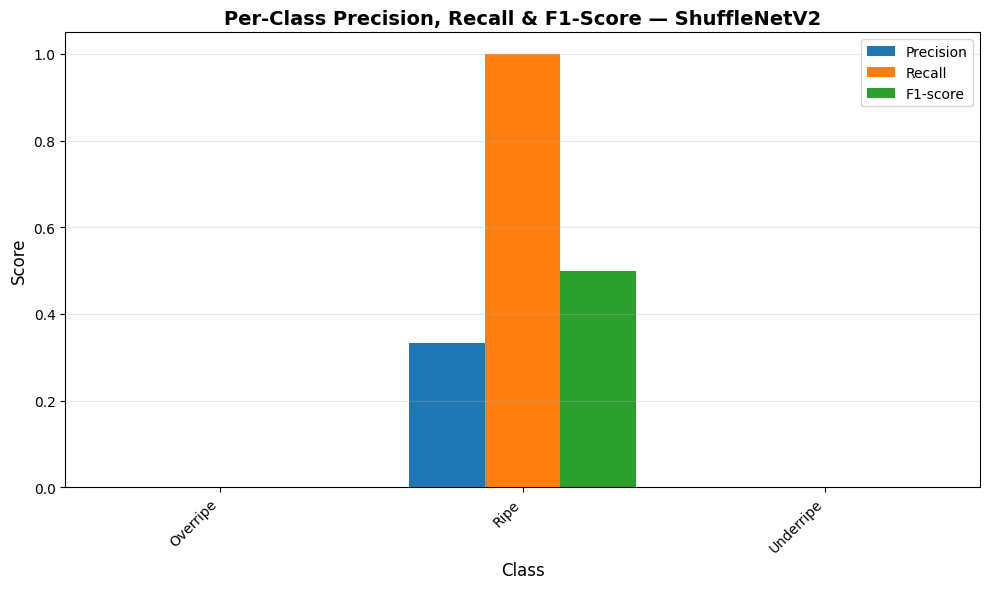

In [39]:
import pandas as pd

if not report_dict:
    print("Skipping metrics bar chart: classification report is unavailable.")
else:
    per_class  = {k: v for k, v in report_dict.items() if k in class_names}
    df_report  = pd.DataFrame(per_class).T

    metrics_to_plot = ["precision", "recall", "f1-score"]
    x     = np.arange(len(class_names))
    width = 0.25

    fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
    for i, metric in enumerate(metrics_to_plot):
        ax_bar.bar(x + i * width, df_report[metric], width, label=metric.capitalize())

    ax_bar.set_xlabel("Class", fontsize=12)
    ax_bar.set_ylabel("Score", fontsize=12)
    ax_bar.set_title("Per-Class Precision, Recall & F1-Score — ShuffleNetV2",
                     fontsize=14, fontweight="bold")
    ax_bar.set_xticks(x + width)
    ax_bar.set_xticklabels(class_names, rotation=45, ha="right")
    ax_bar.set_ylim(0, 1.05)
    ax_bar.legend()
    ax_bar.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    bar_path = os.path.join(MODEL_DIR, f"classification_metrics_{TIMESTAMP}.png")
    fig_bar.savefig(bar_path, dpi=150)
    print(f"Metrics bar chart saved to {bar_path}")
    plt.show()


In [40]:
excel_path = ""

if cm is None or not report_dict:
    print("Skipping Excel export: evaluation outputs are unavailable.")
else:
    full_report = pd.DataFrame(report_dict).T
    full_report.index.name = "Class"

    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    df_cm.index.name   = "True Label"
    df_cm.columns.name = "Predicted Label"

    excel_path = os.path.join(MODEL_DIR, f"classification_report_{TIMESTAMP}.xlsx")
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        full_report.to_excel(writer, sheet_name="Classification Report")
        df_cm.to_excel(writer, sheet_name="Confusion Matrix")

    print(f"Excel report saved to {excel_path}")
    print("\nClassification Report (preview):")
    display(full_report)
    print("\nConfusion Matrix (preview):")
    display(df_cm)


Excel report saved to saved_models\classification_report_20260423_224710.xlsx

Classification Report (preview):


,precision,recall,f1-score,support
Class,,,,
Overripe,0.000000,0.000000,0.000000,60.000000
Ripe,0.333333,1.000000,0.500000,60.000000
Underripe,0.000000,0.000000,0.000000,60.000000
accuracy,0.333333,0.333333,0.333333,0.333333
macro avg,0.111111,0.333333,0.166667,180.000000
weighted avg,0.111111,0.333333,0.166667,180.000000



Confusion Matrix (preview):


Predicted Label,Overripe,Ripe,Underripe
True Label,,,
Overripe,0,60,0
Ripe,0,60,0
Underripe,0,60,0


## 6b. Experiment Log

Each run appends a row to `saved_models/experiment_log.csv`, recording configuration (mode, epochs, batch size, val split, learning rates, width multiplier, dataset sizes) and outcomes (accuracy, macro precision/recall/F1, artifact paths).

This is the **same CSV used by MobileNetV2 and MobileNetV3 notebooks**, enabling direct side-by-side comparison across all candidates in `Model.md` section 8.1.


In [41]:
import csv
import pandas as pd

log_path  = os.path.join(MODEL_DIR, "experiment_log.csv")
log_exists = os.path.exists(log_path)

# Determine run mode label
if DO_TRAIN and DO_FINE_TUNE:
    run_mode = "full_train + fine_tune"
elif DO_TRAIN:
    run_mode = "full_train"
elif DO_SMOKE:
    run_mode = "smoke_test"
else:
    run_mode = "no_training"

# Extract key metrics
if isinstance(report_dict, dict):
    accuracy          = report_dict.get("accuracy", 0)
    macro_f1          = report_dict.get("macro avg", {}).get("f1-score", 0)
    macro_precision   = report_dict.get("macro avg", {}).get("precision", 0)
    macro_recall      = report_dict.get("macro avg", {}).get("recall", 0)
else:
    accuracy = macro_f1 = macro_precision = macro_recall = 0

initial_lr = float(tf.keras.backend.get_value(model.optimizer.learning_rate))
if "history" in locals() and hasattr(history, "history"):
    final_lr = history.history.get("learning_rate", [initial_lr])[-1]
else:
    final_lr = initial_lr

if DO_FINE_TUNE and DO_TRAIN and "ft_model_path" in locals():
    best_model_logged = ft_model_path
else:
    best_model_logged = best_model_path if "best_model_path" in locals() else ""
excel_report_logged = excel_path if "excel_path" in locals() else ""

log_row = {
    "timestamp":           TIMESTAMP,
    "backbone":            f"ShuffleNetV2_x{WIDTH_MULT}",
    "run_mode":            run_mode,
    "epochs_config":       EPOCHS,
    "fine_tune_epochs":    FINE_TUNE_EPOCHS if DO_FINE_TUNE else 0,
    "batch_size":          BATCH_SIZE,
    "val_split":           VAL_SPLIT,
    "initial_learning_rate": initial_lr,
    "final_learning_rate": final_lr,
    "backbone_unfrozen":   True,   # ShuffleNetV2 is always fully trainable
    "train_images":        train_total,
    "test_images":         test_total,
    "num_classes":         num_classes,
    "accuracy":            round(accuracy, 4),
    "macro_precision":     round(macro_precision, 4),
    "macro_recall":        round(macro_recall, 4),
    "macro_f1":            round(macro_f1, 4),
    "best_model_file":     best_model_logged,
    "excel_report":        excel_report_logged,
    "notes":               "",  # add manual notes here if needed
}

with open(log_path, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=log_row.keys())
    if not log_exists:
        writer.writeheader()
    writer.writerow(log_row)

print(f"Experiment logged to {log_path}")
print(f"  Backbone: ShuffleNetV2_x{WIDTH_MULT} | Run: {run_mode}")
print(f"  Acc: {accuracy:.4f} | F1: {macro_f1:.4f}")
print(f"  Initial LR: {initial_lr} | Final LR: {final_lr} | Batch: {BATCH_SIZE}")

log_df = pd.read_csv(log_path)
print(f"\n--- Experiment History ({len(log_df)} runs) ---")
display(log_df)

Experiment logged to saved_models\experiment_log.csv
  Backbone: ShuffleNetV2_x1.0 | Run: full_train + fine_tune
  Acc: 0.3333 | F1: 0.1667
  Initial LR: 4.999999873689376e-06 | Final LR: 4.999999873689376e-05 | Batch: 32

--- Experiment History (4 runs) ---


,timestamp,backbone,run_mode,epochs_config,fine_tune_epochs,batch_size,val_split,initial_learning_rate,final_learning_rate,backbone_unfrozen,train_images,test_images,num_classes,accuracy,macro_precision,macro_recall,macro_f1,best_model_file,excel_report,notes
0,20260423_215953,ShuffleNetV2_x1.0,full_train + fine_tune,30,15,32,0.2,0.000005,0.000050,True,1200,180,3,0.3333,0.1111,0.3333,0.1667,saved_models\palm_ripeness_best_20260423_21595...,saved_models\classification_report_20260423_21...,NaN
1,20260423_222723,ShuffleNetV2_x1.0,full_train + fine_tune,30,15,32,0.2,0.000005,0.000050,True,1200,180,3,0.3333,0.1111,0.3333,0.1667,saved_models\palm_ripeness_best_20260423_22272...,saved_models\classification_report_20260423_22...,NaN
2,20260423_222723,ShuffleNetV2_x1.0,full_train + fine_tune,30,15,32,0.2,0.000005,0.000002,True,1200,180,3,0.3333,0.1111,0.3333,0.1667,saved_models\palm_ripeness_best_20260423_22272...,saved_models\classification_report_20260423_22...,NaN
3,20260423_224710,ShuffleNetV2_x1.0,full_train + fine_tune,30,15,32,0.2,0.000005,0.000050,True,1200,180,3,0.3333,0.1111,0.3333,0.1667,saved_models\palm_ripeness_finetuned_20260423_...,saved_models\classification_report_20260423_22...,NaN


## 7. TFLite Conversion (Command Reference)

After a successful training run, convert the saved H5 checkpoint to TFLite artifacts using the existing pipeline script.  
**Replace `<timestamp>` with the value printed in Cell 1.**

### Convert H5 → FP32 / FP16 / INT8
```bash
python scripts/convert_tflite.py \
    --h5 saved_models/palm_ripeness_best_<timestamp>.h5 \
    --rep-data C:/Users/jeffy/Documents/PSM/Dataset1/Train \
    --output-dir models \
    --preprocess-family shufflenet
```

**Expected outputs** (`models/` directory):
| File | Description |
|---|---|
| `palm_ripeness_best_<new_ts>_fp32.tflite` | Full-precision model |
| `palm_ripeness_best_<new_ts>_float16.tflite` | FP16 quantised (~2× smaller) |
| `palm_ripeness_best_<new_ts>_int8.tflite` | INT8 quantised (~4× smaller) |
| `labels_<new_ts>.json` | Class index → label mapping |
| `tflite_manifest_<new_ts>.json` | Paths + metadata manifest |

> **`--preprocess-family shufflenet`** tells the conversion script to apply `x / 127.5 - 1.0` (not MobileNetV2's `preprocess_input`) when generating the representative calibration dataset. Ensure `scripts/convert_tflite.py` supports this flag — add the family branch if it does not yet exist.

### Validate FP32 vs INT8 accuracy drop
```bash
python scripts/validate_tflite.py \
    --model-fp32 models/palm_ripeness_best_<ts>_fp32.tflite \
    --model-int8 models/palm_ripeness_best_<ts>_int8.tflite \
    --labels models/labels_<ts>.json \
    --data-dir C:/Users/jeffy/Documents/PSM/Dataset1/Test \
    --preprocess-family shufflenet
```

**Pass condition**: relative INT8 drop < 2% (gate defined in `Model.md` section 6.3).  
If gate fails, try **balanced PTQ calibration** (Path B equivalent) or fall back to FP16 deployment — document the outcome in `Record.md`.

### API runtime test
```bash
MODEL_PATH=models/palm_ripeness_best_<ts>_int8.tflite \
LABELS_PATH=models/labels_<ts>.json \
python api/app.py
```
```bash
curl http://127.0.0.1:5000/health
curl -X POST -F "file=@sample_palm.jpg" http://127.0.0.1:5000/classify
```

### CLI latency sampling (Raspberry Pi)
```bash
python scripts/pi_inference.py \
    --model models/palm_ripeness_best_<ts>_int8.tflite \
    --labels models/labels_<ts>.json \
    --image sample_palm.jpg \
    --warmup 1 \
    --runs 10 \
    --preprocess-family shufflenet
```


## 8. Per-File Prediction Helper

`dataset_with_filenames` builds a batched dataset that yields `(image, one_hot_label, filepath)` tuples.  
Useful for per-file error analysis and custom reporting — identical API to the MobileNetV2 helper.


In [42]:
def dataset_with_filenames(root, class_names_list, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    """
    Build a tf.data.Dataset that yields (image, one-hot label, filepath) tuples.
    Preprocessing matches the training pipeline: float32 [-1, 1].

    Args:
        root:             Root folder with one sub-folder per class.
        class_names_list: Ordered list of class names (must match training order).
        img_size:         Target image dimensions.
        batch_size:       Batch size.

    Returns:
        A batched, prefetched tf.data.Dataset of (image, one_hot_label, filepath).
    """
    pattern = os.path.join(root, "*", "*")
    files   = tf.data.Dataset.list_files(pattern, shuffle=False)

    def _process(filepath):
        img = tf.io.read_file(filepath)
        img = tf.image.decode_image(img, channels=3)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)
        # Normalise path separators for Windows compatibility
        normalised = tf.strings.regex_replace(filepath, r"\\\\", "/")
        parts  = tf.strings.split(normalised, "/")
        label  = parts[-2]
        return img, label, filepath

    ds = files.map(_process, num_parallel_calls=AUTOTUNE)

    name_to_index = {name: idx for idx, name in enumerate(class_names_list)}
    keys  = tf.constant(list(name_to_index.keys()))
    vals  = tf.constant(list(name_to_index.values()), dtype=tf.int64)
    table = tf.lookup.StaticHashTable(
        tf.lookup.KeyValueTensorInitializer(keys, vals), default_value=-1
    )

    def _encode_and_preprocess(img, label, filepath):
        # Apply the same preprocessing as the training pipeline
        img_f = tf.cast(img, tf.float32) / 127.5 - 1.0
        idx   = table.lookup(label)
        one_hot = tf.one_hot(idx, depth=len(class_names_list))
        return img_f, one_hot, filepath

    ds = ds.map(_encode_and_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

print("Helper function `dataset_with_filenames(root, class_names_list)` defined.")
print("Example usage:")
print("  ds = dataset_with_filenames(TEST_ROOT, class_names)")
print("  for img, label, path in ds:")
print("      preds = model.predict(img, verbose=0)")


Helper function `dataset_with_filenames(root, class_names_list)` defined.
Example usage:
  ds = dataset_with_filenames(TEST_ROOT, class_names)
  for img, label, path in ds:
      preds = model.predict(img, verbose=0)


## 9. Pipeline Summary

1. **Configure** paths, hyperparameters, and run modes in Cell 1.
2. **Load & split** the training set 80/20; keep the test set completely held out.
3. **Preprocess** images to float32 [-1, 1] (`x / 127.5 - 1.0`); map and prefetch datasets.
4. **Build** the ShuffleNetV2 backbone (channel-split + shuffle blocks) with a data-augmentation prefix and a lightweight classifier head.
5. **Train** with EarlyStopping / ReduceLROnPlateau / ModelCheckpoint; optionally fine-tune at a lower LR.
6. **Evaluate** once on the held-out test set; generate classification report + confusion matrix.
7. **Visualise & export** confusion matrix PNG, metrics bar-chart PNG, and Excel workbook.
8. **Log** run to `saved_models/experiment_log.csv` (same file as MobileNetV2/V3 runs).
9. **Convert** best checkpoint to FP32 / FP16 / INT8 TFLite via `scripts/convert_tflite.py --preprocess-family shufflenet`.
10. **Validate** INT8 accuracy drop against the < 2% gate via `scripts/validate_tflite.py`.
11. **Deploy** via `api/app.py` and `scripts/pi_inference.py`; record latency and thermal observations in `Record.md` and section 8.1 of `Model.md`.

### Preprocessing contract (must be consistent across all stages)
| Stage | Preprocessing applied |
|---|---|
| Training dataset | `x / 127.5 - 1.0` (Cell 5 `preprocess_fn`) |
| Validation dataset | same |
| Test dataset | same |
| Representative dataset for INT8 calibration | `--preprocess-family shufflenet` flag in `convert_tflite.py` |
| TFLite runtime (API + CLI) | `--preprocess-family shufflenet` flag in `pi_inference.py` |
